# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Intifada Afkar Lazain Muhammad | 5054251029|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("diabetes.csv")
print(df.head(5))
print(df.shape)
print(df.info())
print(df.isna().sum())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose             

<Axes: xlabel='Outcome', ylabel='count'>

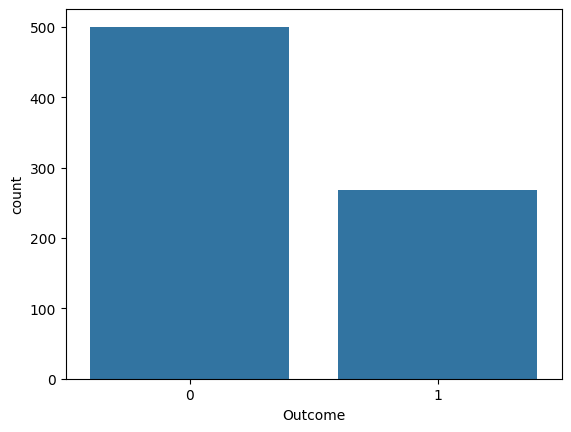

In [4]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
sns.countplot(data=df, x= "Outcome")

In [ ]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.

<Axes: >

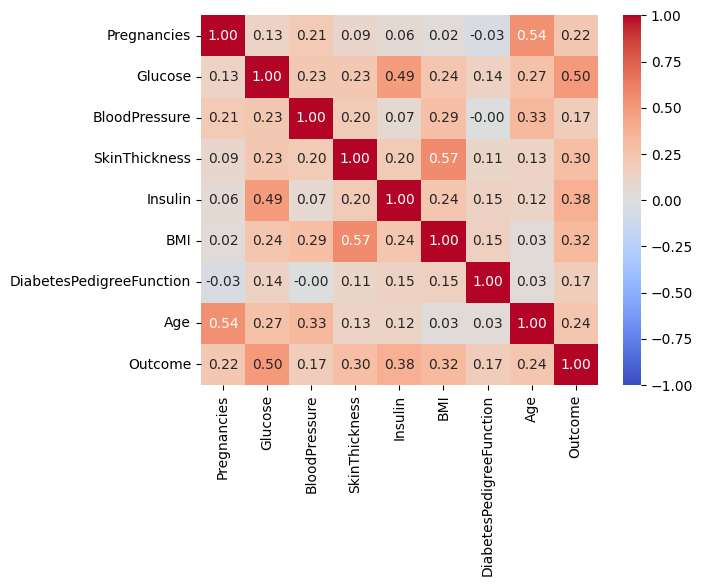

In [6]:
# Tampilkan heatmap korelasi antar fitur.
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [18]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
print("jumlah missing")
print(df.isnull().sum())
print("jumlah nilai 0")
for x in df.columns:
    print(f"{x} = {(df[x] == 0).sum()}")
print(df.nunique())

jumlah missing
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
jumlah nilai 0
Pregnancies = 111
Glucose = 0
BloodPressure = 0
SkinThickness = 0
Insulin = 0
BMI = 0
DiabetesPedigreeFunction = 0
Age = 0
Outcome = 500
Pregnancies                  17
Glucose                     135
BloodPressure                47
SkinThickness                50
Insulin                     187
BMI                         247
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64


In [19]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
print("data 0 pada data sudah merepresentasikan data dengan sesuai, sehingga tidak butuh untuk dilakukan penanganan")

data 0 pada data sudah merepresentasikan data dengan sesuai, sehingga tidak butuh untuk dilakukan penanganan


In [20]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
from sklearn.model_selection import train_test_split

X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribusi kelas keseluruhan:")
print(y.value_counts().sort_index())
print("\nDistribusi kelas train:")
print(y_train.value_counts().sort_index())
print("\nDistribusi kelas test:")
print(y_test.value_counts().sort_index())

Distribusi kelas keseluruhan:
Outcome
0    500
1    268
Name: count, dtype: int64

Distribusi kelas train:
Outcome
0    400
1    214
Name: count, dtype: int64

Distribusi kelas test:
Outcome
0    100
1     54
Name: count, dtype: int64


In [21]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [22]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
from sklearn.naive_bayes import GaussianNB
Model_GaussianNB = GaussianNB()
Model_GaussianNB.fit(X_train_scaled,y_train)

,priors,None
,var_smoothing,1e-09


In [23]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_GNB = Model_GaussianNB.predict(X_test_scaled)

## 3.2 Logistic Regression

In [24]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
from sklearn.linear_model import LogisticRegression
Model_LR = LogisticRegression()
Model_LR.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_LR = Model_LR.predict(X_test_scaled)

# 4. Evaluasi Model

In [28]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
hasil_evaluasi = pd.DataFrame({
    "Model": ["GaussianNB", "LogisticRegression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_GNB),
        accuracy_score(y_test, y_pred_LR),
    ],
    "Precision": [
        precision_score(y_test, y_pred_GNB, zero_division=0),
        precision_score(y_test, y_pred_LR, zero_division=0),
    ],
    "Recall": [
        recall_score(y_test, y_pred_GNB, zero_division=0),
        recall_score(y_test, y_pred_LR, zero_division=0),
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_GNB, zero_division=0),
        f1_score(y_test, y_pred_LR, zero_division=0),
    ]
})

hasil_evaluasi.set_index("Model").round(4)

,Accuracy,Precision,Recall,F1-Score
Model,,,,
GaussianNB,0.7273,0.6034,0.6481,0.6250
LogisticRegression,0.7078,0.5882,0.5556,0.5714


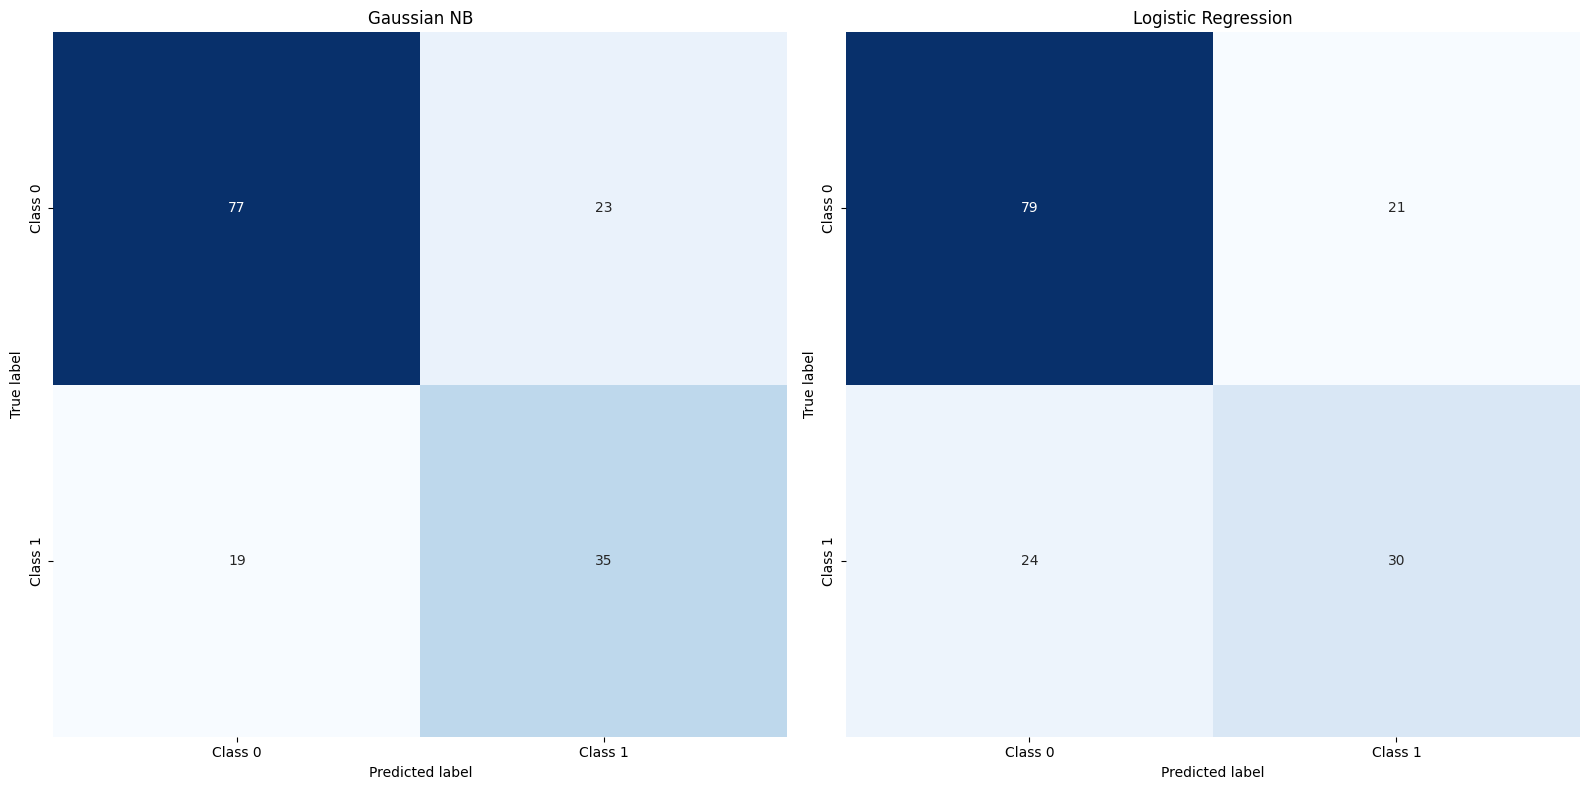

In [30]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
from sklearn.metrics import confusion_matrix

cmGNB = confusion_matrix(y_test, y_pred_GNB)
cmLR = confusion_matrix(y_test, y_pred_LR)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))

for ax, cm, title in zip(
    axes,
    [cmGNB, cmLR],
    ["Gaussian NB", "Logistic Regression"]
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"]
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

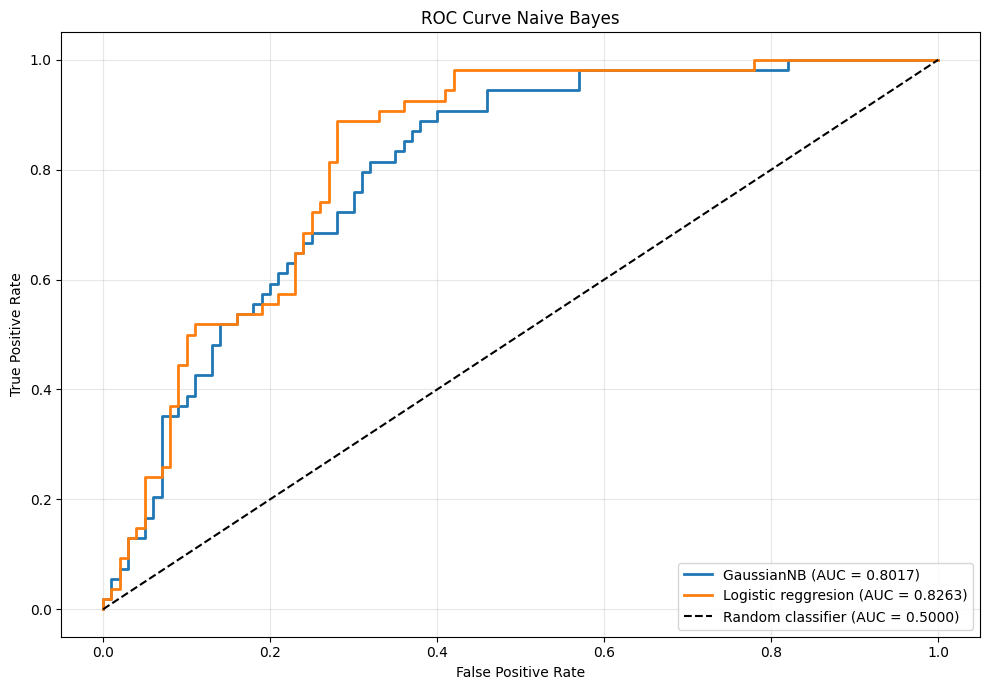

In [32]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
from sklearn.metrics import auc, roc_curve

model_probabilities = {
    "GaussianNB": Model_GaussianNB.predict_proba(X_test_scaled)[:, 1],
    "Logistic reggresion": Model_LR.predict_proba(X_test_scaled)[:, 1],
}

plt.figure(figsize=(10, 7))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    model_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {model_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", label="Random classifier (AUC = 0.5000)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Naive Bayes")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

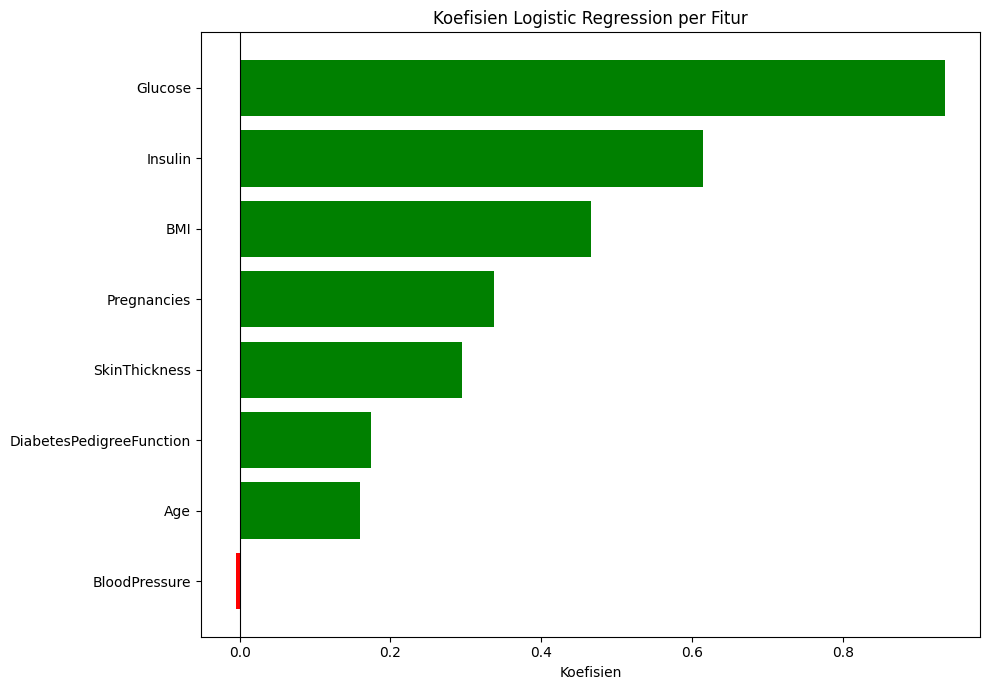

In [ ]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.


# Ambil koefisien dari model (asumsi model sudah di-fit)
coefficients = pd.Series(Model_LR.coef_[0], index=X_train.columns)
coefficients = coefficients.sort_values()

# Warna: hijau untuk positif, merah untuk negatif
colors = ['green' if c > 0 else 'red' for c in coefficients]

plt.figure(figsize=(10, 7))
plt.barh(coefficients.index, coefficients.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel("Koefisien")
plt.title("Koefisien Logistic Regression per Fitur")
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Gaussian Naive Bayes dan Logistic Regression berdasarkan hasil evaluasi. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

Data merupakan data imbalance dengan rasio sekitar 66:33

Data tidak memiliki missing value dan nilai 0 pada data wajar karena pada pregnant menandakan bahwa orang itu tidak pernah hamil dan pada outcome menunjukkan jika orang itu tidak terkena diabetes

Dilihat dari korelasinya Glukosa(0.5) menjadi faktor terbesar diabetes diikuti insulin dan BMI

Dari tabel peforma Gaussian NB menang diatas Logistik reggresion dari segala aspek baik menebak class minoritas maupun accuracy secara overall

Dari confussion matrix terlihat bahwa Gaussian NB bisa menebak class minoritas lebih baik walau class mayoritasnya kalah sedikit dibanding logistik reggression

Pada ROC menunjukkan bahwa Logistik Reggresion lebih baik dalam menrank keseluruhan data test dari 0-1 (dari kemungkinan 0 diabetes sampai 1 diabetes) secara urut lebih baik,kemungkinan jika dilakukan tuning pada parameter model Logistik Reggresion maka bisa mengungguli Gaussian NB.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Kesimpulan:

Pada data yang kecil seperti data pada notebook ini Gaussian Bayes lebih baik daripada Logistik Reggresion baik dari menebak class minoritas maupun akurasi secara overall tapi ada kemungkinan dengan melakukan tuning pada parameter logistik reggresion bisa menyamai Gaussian Bayes

Rekomendasi:

Bisa dicoba untuk melakukan tuning pada parameter logistik reggresion untuk melihat potensi maksimum dari model tersebut